In [1]:


#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.


In [2]:
#hide
from fastbook import *
from fastai.vision.all import *
path = untar_data(URLs.PETS)

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:37&lt;00:00]</div>

In [3]:
Path.BASE_PATH = path

In [4]:
path.ls()

[Path('images'), Path('annotations')]

In [5]:
(path/"images").ls()

(#7393) [Path('images/beagle_115.jpg'), Path('images/boxer_18.jpg'), Path('images/Maine_Coon_157.jpg'), Path('images/scottish_terrier_28.jpg'), Path('images/english_setter_6.jpg'), Path('images/american_pit_bull_terrier_79.jpg'), Path('images/boxer_128.jpg'), Path('images/Persian_265.jpg'), Path('images/Maine_Coon_182.jpg'), Path('images/keeshond_89.jpg'), Path('images/chihuahua_82.jpg'), Path('images/basset_hound_5.jpg'), Path('images/english_cocker_spaniel_144.jpg'), Path('images/scottish_terrier_108.jpg'), Path('images/British_Shorthair_116.jpg'), Path('images/boxer_10.jpg'), Path('images/basset_hound_194.jpg'), Path('images/beagle_85.jpg'), Path('images/japanese_chin_87.jpg'), Path('images/pug_40.jpg'), Path('images/chihuahua_199.jpg'), Path('images/english_setter_152.jpg'), Path('images/Bengal_98.jpg'), Path('images/chihuahua_174.jpg'), Path('images/leonberger_166.jpg'), Path('images/german_shorthaired_68.jpg'), Path('images/miniature_pinscher_27.jpg'), Path('images/Ragdoll_257.jp

In [6]:
fname = (path/"images").ls()[0]
re.findall(r'(.+)_\d+.jpg$', fname.name)

['beagle']

Resnet50 with default weights.

In [9]:
#Model instantiation
from torchvision.models import resnet50, ResNet50_Weights



In [10]:

NUM_EPOCHS=20
pets = DataBlock(blocks = (ImageBlock, CategoryBlock), 
                 get_items=get_image_files, 
                 splitter=RandomSplitter(seed=42),
                 get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'),
                 item_tfms=Resize(460), 
                 batch_tfms=aug_transforms(size=224, min_scale=0.75))



dls = pets.dataloaders(path/"images")
total_samples = len(dls.train.dataset)
NUM_CLASSES = dls.c
criterion = nn.CrossEntropyLoss()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def make_model():
    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    num_in_features = model.fc.in_features

    
    # 4. Replace the 'fc' layer with a new one
    # This new layer starts with RANDOM weights (uncalibrated)
    model.fc = nn.Linear(num_in_features, NUM_CLASSES)
    
    # 5. Move to GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    return model

def train_and_evaluate(opt, model, criterion):

    model.to(device)
    model.train()
    
    train_history=[]
    valid_history=[]
    valid_acc_history=[]
    for epoch in range(NUM_EPOCHS):
        total_train_loss=0
        for inputs, labels in dls.train:
            inputs = inputs.as_subclass(torch.Tensor)
            labels = labels.as_subclass(torch.Tensor)
            opt.zero_grad()
            outputs=model(inputs)
            loss=criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
    
        avg_train_loss = total_train_loss/len(dls.train)
        train_history.append(avg_train_loss)
    
        model.eval()
        total_valid_loss=0
        total=0
        correct=0
        with torch.no_grad():
            for inputs, labels in dls.valid:
                inputs = inputs.as_subclass(torch.Tensor)
                labels = labels.as_subclass(torch.Tensor)
                assert inputs.ndim == 4
                assert inputs.shape[1:] == (3, 224, 224)
                assert inputs.shape[0] <= 64
                assert labels.ndim == 1
                assert labels.shape[0] == inputs.shape[0]
                outputs = model(inputs)
                assert outputs.ndim == 2
                assert outputs.shape[1:] == (NUM_CLASSES,)
                assert outputs.shape[0] == inputs.shape[0]
                loss = criterion(outputs, labels)
                total_valid_loss += loss.item()
                # Calculate Accuracy
                # outputs.max(1) returns (values, indices). We want indices [1].
                _, predicted = torch.max(outputs, 1)
                assert predicted.ndim == 1
                assert predicted.shape == labels.shape
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        # Average validation loss for this epoch
        avg_valid_loss = total_valid_loss / len(dls.valid)
        valid_history.append(avg_valid_loss)
        valid_acc_history.append(correct/total)
    plot_results(train_history, valid_history, valid_acc_history)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_results(train_loss, valid_loss, valid_acc):
    epochs = range(1, len(train_loss) + 1)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- LEFT AXIS (LOSS) ---
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss', color='tab:red')
    
    # Plotting lines
    l1, = ax1.plot(epochs, train_loss, label='Train Loss', color='tab:red', linestyle='--')
    l2, = ax1.plot(epochs, valid_loss, label='Valid Loss', color='tab:red')
    
    # Annotate the final points
    ax1.annotate(f'{train_loss[-1]:.2f}', (epochs[-1], train_loss[-1]), 
                 textcoords="offset points", xytext=(0,10), ha='center', color='tab:red')
    ax1.annotate(f'{valid_loss[-1]:.2f}', (epochs[-1], valid_loss[-1]), 
                 textcoords="offset points", xytext=(0,-15), ha='center', color='tab:red')

    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- RIGHT AXIS (ACCURACY) ---
    ax2 = ax1.twinx() 
    ax2.set_ylabel('Accuracy (%)', color='tab:blue')
    l3, = ax2.plot(epochs, valid_acc, label='Valid Accuracy', color='tab:blue', linewidth=2)
    
    # Annotate the final accuracy
    ax2.annotate(f'{valid_acc[-1]:.1f}%', (epochs[-1], valid_acc[-1]), 
                 textcoords="offset points", xytext=(0,10), ha='center', color='tab:blue')

    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(5.0))

    # --- FINAL CLEANUP ---
    plt.title('Training Profile: Loss vs. Accuracy')
    ax1.legend([l1, l2, l3], ['Train Loss', 'Valid Loss', 'Valid Accuracy'], loc='best')

    plt.show()
    

Control group 1 - Hardcoded learning rate(10^-3), All layers trained, Not warming up.

Preconditions - Trained for 20 epochs, cross entropy loss, stochastic gradient optimizer with no momentum.

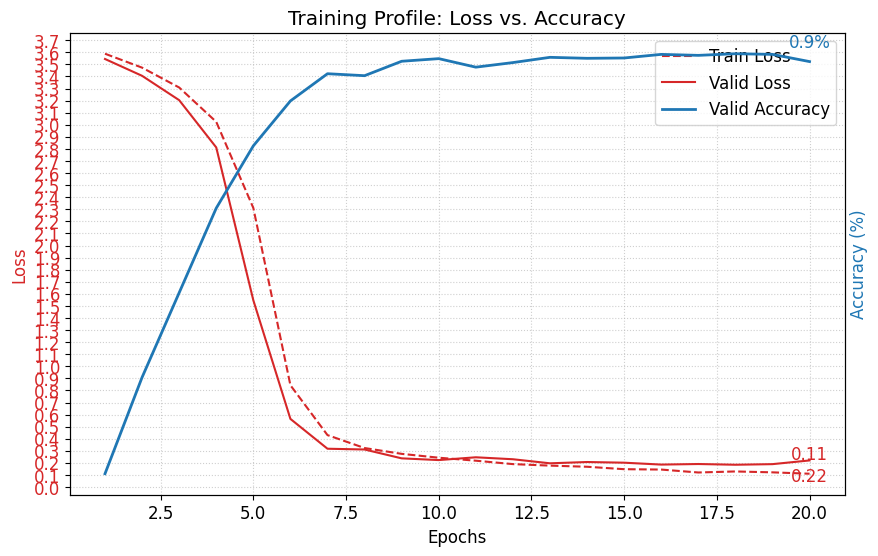

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim

LEARNING_RATE=10**-3
model = make_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.0)

train_and_evaluate(optimizer, model, criterion)

Control group 2 - Discriminative learning(10^-3/3^(x) where x is index of the layer from the output with output being the 0th layer)
All layers trained, Not warming up.

Preconditions - Trained for 20 epochs, cross entropy loss, stochastic gradient optimizer with no momentum.

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ab170970400>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7ab170970400>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
^    ^self._shutdown_workers()^

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self._parent_pid == os.getpid(), 'can only test a child process'if w.is_alive():

             ^ ^^ ^^  ^ ^^^^^^^^^^^^
^  Fil

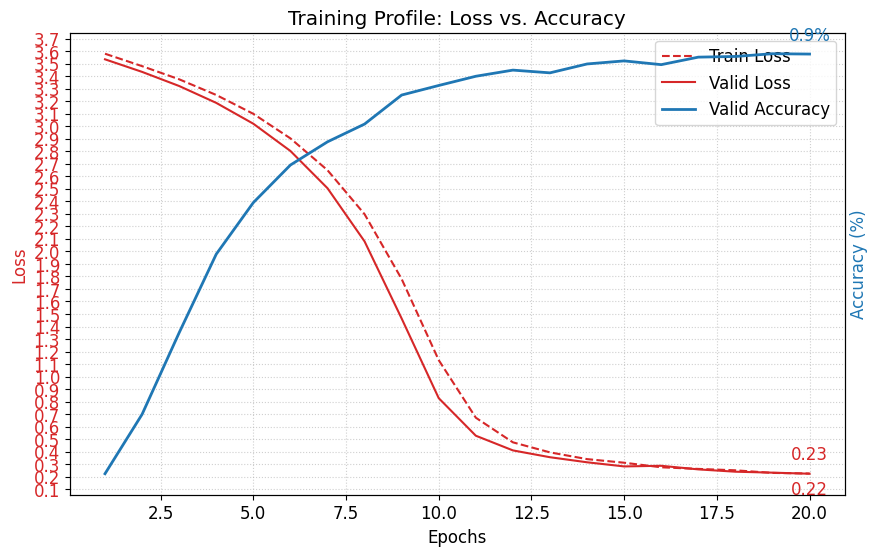

In [48]:
# 1. Define your layer order (from output back to input)
# We include the 'fc' (output) layer first, then the sequential layers in reverse
model = make_model()
layer_groups = [model.fc, model.layer4, model.layer3, model.layer2, model.layer1, model.conv1]

# 2. Build the parameter groups with the calculated learning rates
param_groups = []
for x, layer in enumerate(layer_groups):
    lr = (1e-3) / (3 ** x)
    param_groups.append({
        'params': layer.parameters(),
        'lr': lr
    })

# 3. Pass to the optimizer
optimizer = torch.optim.SGD(param_groups, momentum=0.0)


train_and_evaluate(optimizer, model, criterion)

Control group 3 - Discriminative learning(10^-3/3^(x) where x is index of the layer from the output with output being the 0th layer)
Only last block trained, Not warming up.

Preconditions - Trained for 20 epochs, cross entropy loss, stochastic gradient optimizer with no momentum.

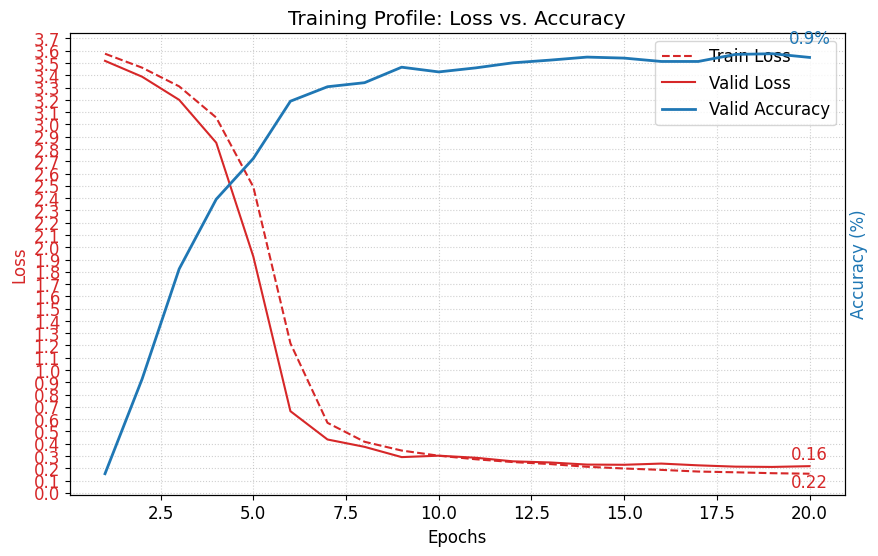

In [ ]:
# 1. Define your layer order (from output back to input)
# We include the 'fc' (output) layer first, then the sequential layers in reverse
model = make_model()
layer_groups = [model.fc, model.layer4]
LEARNING_RATE=10**-3
# 2. Build the parameter groups with the calculated learning rates
param_groups = []
for x, layer in enumerate(layer_groups):
    lr = (1e-3) / (3 ** x)
    param_groups.append({
        'params': layer.parameters(),
        'lr': lr
    })

# 3. Pass to the optimizer
optimizer = torch.optim.SGD(param_groups, momentum=0.0)


train_and_evaluate(optimizer, model, criterion)

Control group 4 - Fixed learning rate, Only last block trained, Not warming up.

Preconditions - Trained for 20 epochs, cross entropy loss, stochastic gradient optimizer with no momentum.

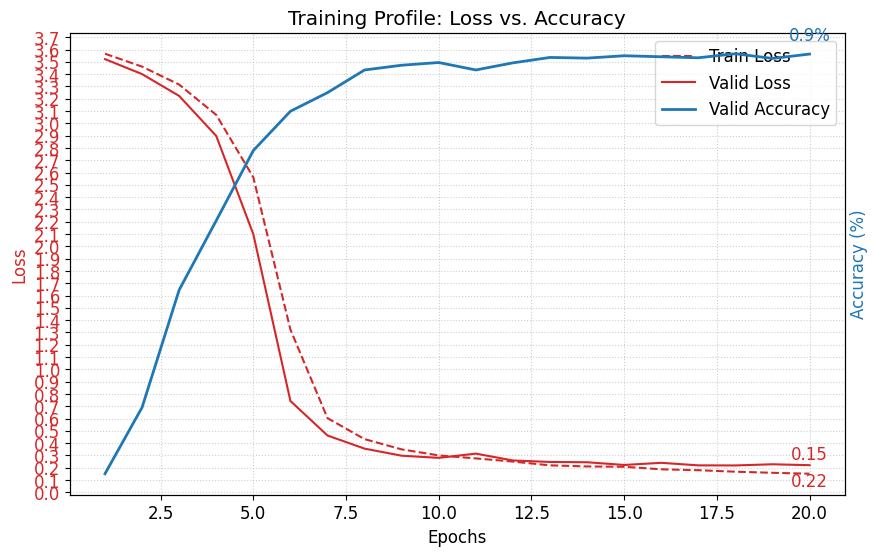

In [50]:
# 1. Define your layer order (from output back to input)
# We include the 'fc' (output) layer first, then the sequential layers in reverse
model = make_model()
layer_groups = [model.fc, model.layer4]

param_groups = []
for x, layer in enumerate(layer_groups):
    lr = LEARNING_RATE
    param_groups.append({
        'params': layer.parameters(),
        'lr': lr
    })

# 3. Pass to the optimizer
optimizer = torch.optim.SGD(param_groups, momentum=0.0)


train_and_evaluate(optimizer, model, criterion)

In [3]:
NUM_EPOCHS=35

Control group 1, but more epochs

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

LEARNING_RATE=10**-3
model = make_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.0)

train_and_evaluate(optimizer, model, criterion)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


Control group 2 - Discriminative learning(10^-3/3^(x) where x is index of the layer from the output with output being the 0th layer)
All layers trained, Not warming up.

Preconditions - Trained for 20 epochs, cross entropy loss, stochastic gradient optimizer with no momentum.

In [ ]:
# 1. Define your layer order (from output back to input)
# We include the 'fc' (output) layer first, then the sequential layers in reverse
model = make_model()
layer_groups = [model.fc, model.layer4, model.layer3, model.layer2, model.layer1, model.conv1]

# 2. Build the parameter groups with the calculated learning rates
param_groups = []
for x, layer in enumerate(layer_groups):
    lr = (1e-3) / (3 ** x)
    param_groups.append({
        'params': layer.parameters(),
        'lr': lr
    })

# 3. Pass to the optimizer
optimizer = torch.optim.SGD(param_groups, momentum=0.0)


train_and_evaluate(optimizer, model, criterion)

Control group 3, with more epochs

In [ ]:
# 1. Define your layer order (from output back to input)
# We include the 'fc' (output) layer first, then the sequential layers in reverse
model = make_model()
layer_groups = [model.fc, model.layer4]
LEARNING_RATE=10**-3
# 2. Build the parameter groups with the calculated learning rates
param_groups = []
for x, layer in enumerate(layer_groups):
    param_groups.append({
        'params': layer.parameters(),
        'lr': LEARNING_RATE
    })

# 3. Pass to the optimizer
optimizer = torch.optim.SGD(param_groups, momentum=0.0)


train_and_evaluate(optimizer, model, criterion)

Control group 4, with more epochs

In [ ]:
# 1. Define your layer order (from output back to input)
# We include the 'fc' (output) layer first, then the sequential layers in reverse
model = make_model()
layer_groups = [model.fc, model.layer4]

param_groups = []
for x, layer in enumerate(layer_groups):
    lr = LEARNING_RATE
    param_groups.append({
        'params': layer.parameters(),
        'lr': lr
    })

# 3. Pass to the optimizer
optimizer = torch.optim.SGD(param_groups, momentum=0.0)


train_and_evaluate(optimizer, model, criterion)

In [ ]:
!pip install -U git+https://github.com/fastai/fastprogress.git

In [ ]:

learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2)

In [ ]:
preds,_ = learn.get_preds(dl=[(x,y)])
preds[0]

In [ ]:
len(preds[0]),preds[0].sum()

In [ ]:
torch.random.manual_seed(69);

In [ ]:
acts = torch.randn((6,2))*2
acts

In [ ]:
acts.sigmoid()

In [ ]:
secondClass=(acts[:,1]-acts[:, 0]).sigmoid()
print(1-secondClass)
print(secondClass)


In [ ]:

sm_acts = torch.softmax(acts, dim=1)
sm_acts

In multi-categorical classification, we use functions like softmax in the final layer since they return an output summing to 1 where each value can be interpreted as probability of the prediction.




In [ ]:
idx=range(6)
targs=[1, 0, 0, 0, 1, 1]
print(sm_acts[idx,targs])

In [ ]:
df = pd.DataFrame(sm_acts, columns=["3","7"])
df['targ'] = targs
df['idx'] = idx
df['result'] = sm_acts[range(6), targs]
# To this:
t = df.style.hide()
#To have html code compatible with our script
# Just display the styled dataframe directly
display(df.style.hide())


In [ ]:
loss_func = nn.CrossEntropyLoss()